# Applying Function Approximation on Real-World ML Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply function approximation on real-world ML models
- Understand power series and function approximations
- Use Taylor series for function approximation
- Apply approximations to optimize ML models

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 02 "The Neuron, Perceptron, and XOR Problem" — a single perceptron failed on XOR because a straight line cannot approximate that function; here "approximate a function" becomes precise.

---

This notebook covers practical activities from **Course 03, Unit 2**:
- Applying function approximation on real-world ML models

---

## Introduction

**Function approximation** allows us to approximate complex functions using simpler forms (like power series), which is essential for optimization and understanding model behavior in machine learning.


---

## 📌 Real case: the theorem everybody quotes and almost nobody quotes correctly

In 1989 George Cybenko proved that a feedforward network with a **single hidden layer** and a sigmoidal
activation can approximate any continuous function on a compact set to any desired accuracy. Hornik,
Stinchcombe and White proved a more general version the same year. This is the **universal approximation
theorem**, and it is cited in the introduction of an enormous number of papers, usually as evidence that
neural networks can learn anything.

Read what it actually says. It is an **existence** result: for any target accuracy, *there exists* a set of
weights that achieves it. It gives no bound on how many hidden units you need — the width can grow
exponentially with the input dimension. It says nothing about whether gradient descent will *find* those
weights. And it says nothing whatsoever about data the network has not seen: approximating a function on
the training points is not the same as generalising. Both papers are in this notebook's reference list;
they are worth reading precisely because the theorem is weaker and more interesting than its reputation.

**What goes wrong without this.** Approximation theory is how you know *why* a model class can or cannot
represent something. Course 01 showed a single perceptron failing on XOR — that failure is an approximation
statement, not a training problem: no straight line exists. Knowing the difference between "my optimiser
failed" and "my model class cannot express this" is the difference between tuning for a week and changing
the architecture in an afternoon.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy/Matplotlib plus scipy.optimize, sklearn's LinearRegression, and the
# real diabetes dataset whose loss surface we approximate in Part 2.

import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error

# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nApplying Function Approximation on Real-World ML Models")
print("=" * 60)


✅ Libraries imported!

Applying Function Approximation on Real-World ML Models


## Part 1: Taylor Series Approximation


Part 1: Taylor Series Approximation


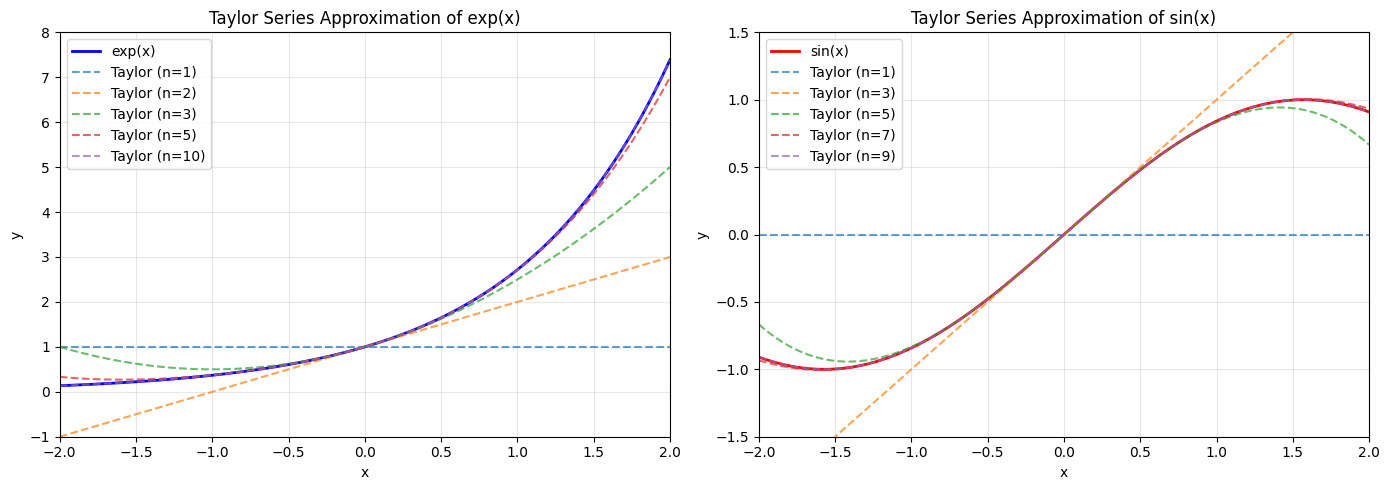


✅ Taylor series approximations visualized!


In [2]:
# Build Taylor-series approximations of exp(x) and sin(x) and watch them improve with more terms.
# Taylor's idea — replace a hard function with polynomials — underpins optimization analysis in ML.

print("=" * 60)
print("Part 1: Taylor Series Approximation")
print("=" * 60)
# Taylor series: f(x) ≈ f(a) + f'(a)(x-a) + f''(a)(x-a)²/2! + ...
def exp_taylor(x, a=0, n_terms=5):
    """Taylor series approximation of exp(x) around point a"""
    result = 0
    x_minus_a = x - a
    for n in range(n_terms):
        # f^(n)(a) = exp(a) for all n
        result += (np.exp(a) * (x_minus_a)**n) / math.factorial(n)
    return result

def sin_taylor(x, a=0, n_terms=5):
    """Taylor series approximation of sin(x) around point a"""
    result = 0
    x_minus_a = x - a
    for n in range(n_terms):
        # Derivatives of sin cycle: sin, cos, -sin, -cos
        derivatives = [np.sin(a), np.cos(a), -np.sin(a), -np.cos(a)]
        result += (derivatives[n % 4] * (x_minus_a)**n) / math.factorial(n)
    return result

# Visualize approximations
x = np.linspace(-2, 2, 100)
plt.figure(figsize=(14, 5))
# Exponential approximation
plt.subplot(1, 2, 1)
plt.plot(x, np.exp(x), 'b-', label='exp(x)', linewidth=2)
for n in [1, 2, 3, 5, 10]:
    y_approx = [exp_taylor(xi, a=0, n_terms=n) for xi in x]
    plt.plot(x, y_approx, '--', label=f'Taylor (n={n})', alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Taylor Series Approximation of exp(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-2, 2)
plt.ylim(-1, 8)
# Sine approximation
plt.subplot(1, 2, 2)
plt.plot(x, np.sin(x), 'r-', label='sin(x)', linewidth=2)
for n in [1, 3, 5, 7, 9]:
    y_approx = [sin_taylor(xi, a=0, n_terms=n) for xi in x]
    plt.plot(x, y_approx, '--', label=f'Taylor (n={n})', alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Taylor Series Approximation of sin(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-2, 2)
plt.ylim(-1.5, 1.5)
plt.tight_layout()
plt.show()
print("\n✅ Taylor series approximations visualized!")


**Read the figure.** Two functions, each drawn against its own Taylor approximations built at a = 0. The
solid curve is the truth; every dashed curve is a polynomial with a stated number of terms.

- **Left, exp(x).** `n=1` is the flat line at 1 — one term knows only the height at x = 0. `n=2` adds the
  slope and becomes the straight line 1 + x. `n=3` bends into a parabola. By `n=5` the dashed curve is
  hard to separate from the blue exp(x) between about −1.5 and +1.5, and `n=10` is indistinguishable from
  it across the whole window.
- **Right, sin(x).** Same story: `n=1` is flat at 0, `n=3` is the straight line x that shoots off past
  x = 1.5, `n=5` follows sin(x) until it peels away near the edges, and `n=7` and `n=9` sit on the red
  curve everywhere shown.
- Read where the errors are: every approximation is **best at x = 0 and worst at the edges**, and adding
  terms widens the region where it is good rather than lifting it uniformly. That is what "local" means —
  a Taylor series is a statement about a neighbourhood of one point, not about the function everywhere.

This is why the next part expands a *loss* around its optimum: near a minimum, the local picture is the one
that matters.


## Part 2: Function Approximation in ML Loss Functions



Part 2: Function Approximation in ML Loss Functions

Dataset: diabetes progression vs BMI - 442 real patients
Correlation(BMI, progression) = 0.5865

Optimal parameters: w=0.5865, b=-0.0000

Optimal loss: 0.6561
Gradient at optimum: [0.000000, 0.000000]
Hessian at optimum:
[[2.00000000e+00 8.32667268e-11]
 [8.32667268e-11 2.00000000e+00]]


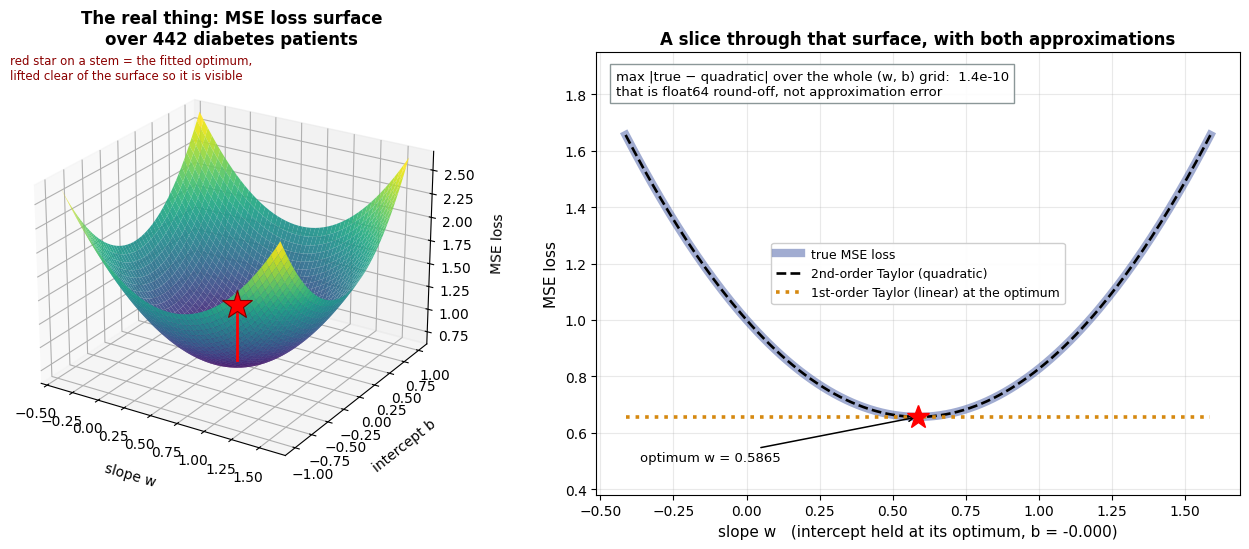


Why the two surfaces match so well: for linear regression with MSE the loss is
EXACTLY quadratic in (w, b), so the 2nd-order Taylor expansion is not an approximation
at all - it is the function. For a neural network it would only be a local likeness.
Max |true - approx| over the grid: 1.41e-10

✅ Function approximation applied to a REAL ML loss function!


In [3]:
# Approximate a REAL MSE loss surface by its 2nd-order Taylor expansion around the optimum.
# Near a minimum every smooth loss looks quadratic - the insight behind Newton's method and learning-rate theory.

print("\n" + "=" * 60)
print("Part 2: Function Approximation in ML Loss Functions")
print("=" * 60)

# Real data: sklearn's diabetes study - 442 patients. We regress disease progression
# one year after baseline on a single real predictor, body mass index.
diabetes = load_diabetes()
bmi_index = diabetes.feature_names.index("bmi")
X_raw = diabetes.data[:, [bmi_index]]
y_raw = diabetes.target

# Standardize both sides so the parameter grid below is on a readable scale.
# Handy consequence: with standardized x and y, the optimal slope IS the correlation
# between BMI and disease progression.
X = (X_raw - X_raw.mean()) / X_raw.std()
y = (y_raw - y_raw.mean()) / y_raw.std()

print(f"\nDataset: diabetes progression vs BMI - {X.shape[0]} real patients")
print(f"Correlation(BMI, progression) = {np.corrcoef(X.flatten(), y)[0, 1]:.4f}")

# Fit linear regression
model = LinearRegression()
model.fit(X, y)
w_opt = model.coef_[0]
b_opt = model.intercept_
print(f"\nOptimal parameters: w={w_opt:.4f}, b={b_opt:.4f}")
# Define loss function
def loss_function(w, b):
    y_pred = w * X.flatten() + b
    return mean_squared_error(y, y_pred)
# Create grid around optimal point
w_range = np.linspace(w_opt - 1, w_opt + 1, 50)
b_range = np.linspace(b_opt - 1, b_opt + 1, 50)
W, B = np.meshgrid(w_range, b_range)
# Compute loss surface
loss_surface = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        loss_surface[i, j] = loss_function(W[i, j], B[i, j])
# Quadratic approximation (Taylor series up to 2nd order)
# L(w, b) ≈ L(w_opt, b_opt) + gradient^T * [w-w_opt, b-b_opt] + 0.5 * [w-w_opt, b-b_opt]^T * Hessian * [w-w_opt, b-b_opt]
# Compute gradient numerically
def compute_gradient(w, b, h=1e-5):
    grad_w = (loss_function(w + h, b) - loss_function(w - h, b)) / (2 * h)
    grad_b = (loss_function(w, b + h) - loss_function(w, b - h)) / (2 * h)
    return grad_w, grad_b
# Compute Hessian numerically
def compute_hessian(w, b, h=1e-3):
    gw_wplus, gb_wplus = compute_gradient(w + h, b, h)
    gw_wminus, gb_wminus = compute_gradient(w - h, b, h)
    grad_w_w = (gw_wplus - gw_wminus) / (2 * h)
    grad_b_w = (gb_wplus - gb_wminus) / (2 * h)
    gw_bplus, gb_bplus = compute_gradient(w, b + h, h)
    gw_bminus, gb_bminus = compute_gradient(w, b - h, h)
    grad_w_b = (gw_bplus - gw_bminus) / (2 * h)
    grad_b_b = (gb_bplus - gb_bminus) / (2 * h)
    return np.array([[grad_w_w, grad_w_b], [grad_b_w, grad_b_b]])
grad_w, grad_b = compute_gradient(w_opt, b_opt)
hessian = compute_hessian(w_opt, b_opt)
loss_opt = loss_function(w_opt, b_opt)
print(f"\nOptimal loss: {loss_opt:.4f}")
print(f"Gradient at optimum: [{grad_w:.6f}, {grad_b:.6f}]")
print(f"Hessian at optimum:\n{hessian}")
# Quadratic approximation
def quadratic_approximation(w, b):
    dw = w - w_opt
    db = b - b_opt
    delta = np.array([dw, db])
    return loss_opt + np.array([grad_w, grad_b]) @ delta + 0.5 * delta @ hessian @ delta
# Visualize
loss_approx = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        loss_approx[i, j] = quadratic_approximation(W[i, j], B[i, j])
# WHY not two 3-D surfaces side by side: two separately-drawn bowls look alike whatever
# the numbers say, so the picture cannot prove agreement. Instead: the real surface once,
# then a SLICE through it on which the true loss and its approximations are drawn on the
# same axis, where a mismatch would be impossible to hide.
fig = plt.figure(figsize=(13.6, 5.6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(W, B, loss_surface, cmap='viridis', alpha=0.92, linewidth=0, antialiased=True)
# A marker AT the floor of the bowl is hidden by the surface itself, so put the star on a
# short stem above it: the stem's foot is the optimum, the star is where you can see it.
ax1.plot([w_opt, w_opt], [b_opt, b_opt], [loss_opt, loss_opt + 0.6],
         color='red', lw=2.0, zorder=10)
# Line3D rather than scatter: a 3-D scatter marker gets depth-sorted behind the surface.
ax1.plot([w_opt], [b_opt], [loss_opt + 0.6], marker='*', color='red', ms=22,
         markeredgecolor='#7b0000', markeredgewidth=0.8, zorder=11)
ax1.set_xlabel('slope w', labelpad=9)
ax1.set_ylabel('intercept b', labelpad=9)
ax1.set_zlabel('MSE loss', labelpad=9)
ax1.set_title('The real thing: MSE loss surface\nover 442 diabetes patients',
              fontsize=12, fontweight='bold')
ax1.view_init(elev=24, azim=-58)
ax1.text2D(0.00, 0.94, 'red star on a stem = the fitted optimum,\nlifted clear of the surface so it is visible',
           transform=ax1.transAxes, fontsize=8.5, color='#8b0000')

# Cut the surface along b = b_opt and put all three curves on one axis.
ax2 = fig.add_subplot(1, 2, 2)
w_line = np.linspace(w_opt - 1, w_opt + 1, 200)
true_line = np.array([loss_function(w, b_opt) for w in w_line])
quad_line = np.array([quadratic_approximation(w, b_opt) for w in w_line])
lin_line = loss_opt + grad_w * (w_line - w_opt)        # 1st-order expansion AT the optimum
ax2.plot(w_line, true_line, color='#1f3a93', lw=6, alpha=0.42, label='true MSE loss')
ax2.plot(w_line, quad_line, 'k--', lw=1.9, label='2nd-order Taylor (quadratic)')
ax2.plot(w_line, lin_line, ls=':', color='#d68910', lw=2.6,
         label='1st-order Taylor (linear) at the optimum')
ax2.plot([w_opt], [loss_opt], 'r*', ms=17, zorder=6)
ax2.annotate(f'optimum w = {w_opt:.4f}', xy=(w_opt, loss_opt),
             xytext=(w_opt - 0.95, 0.50), fontsize=9.5,
             arrowprops=dict(arrowstyle='->', lw=1.1))
max_gap = np.max(np.abs(loss_surface - loss_approx))
ax2.text(0.03, 0.96, f'max |true − quadratic| over the whole (w, b) grid:  {max_gap:.1e}\n'
                     f'that is float64 round-off, not approximation error',
         transform=ax2.transAxes, va='top', fontsize=9.5,
         bbox=dict(facecolor='white', edgecolor='#7f8c8d', alpha=0.9))
ax2.set_xlabel(f'slope w   (intercept held at its optimum, b = {b_opt:.3f})', fontsize=11)
ax2.set_ylabel('MSE loss', fontsize=11)
ax2.set_title('A slice through that surface, with both approximations',
              fontsize=12, fontweight='bold')
ax2.set_ylim(0.38, 1.95)
ax2.legend(loc='center', fontsize=9, framealpha=0.95)
ax2.grid(True, alpha=0.28)

plt.tight_layout()
plt.show()
print("\nWhy the two surfaces match so well: for linear regression with MSE the loss is")
print("EXACTLY quadratic in (w, b), so the 2nd-order Taylor expansion is not an approximation")
print("at all - it is the function. For a neural network it would only be a local likeness.")
print(f"Max |true - approx| over the grid: {np.max(np.abs(loss_surface - loss_approx)):.2e}")

print("\n✅ Function approximation applied to a REAL ML loss function!")


**Read the figure.** Real data throughout: 442 diabetes patients, disease progression regressed on BMI,
both standardised.

- **Left** — the true MSE loss over the two parameters. It is a **bowl**, and the red star — lifted onto a short
  stem so the surface cannot hide it — stands over the fit `LinearRegression` returned (w = 0.5865, which for standardised variables is exactly the
  correlation between BMI and progression).
- **Right** — a straight cut through that bowl at the optimal intercept, so the true loss and its two
  Taylor approximations can be compared on one axis. The **thick pale-blue curve is the true loss**; the
  **black dashed curve is its 2nd-order Taylor expansion**, and it does not merely track the blue curve —
  it lies on it for the entire ±1 window. The box gives the honest measurement: the largest gap anywhere
  on the full two-dimensional grid is about 1e-10, which is float64 round-off, not approximation error.
  For linear regression with MSE the loss **is** a quadratic, so its 2nd-order expansion is not an
  approximation at all.
- The **orange dotted line is the 1st-order (linear) expansion at the optimum, and it is flat.** That is
  not a drawing mistake: the gradient at a minimum is zero, so a first-order model of the loss there
  carries no information at all — it cannot see the bowl. Curvature only shows up in the second-order
  term, which is why Newton-type methods and learning-rate rules are written in terms of the Hessian.

The flat orange line is also the setup for Part 3: a linear approximation is useful precisely **away** from
the optimum, where the gradient is not zero.


## Part 3: Linear Approximation for Optimization



Part 3: Linear Approximation for Optimization

Starting point: x0 = 0.0
Optimal point: x* = 2.9654 (true optimum: 3.0)
Final function value: f(x*) = 0.001196


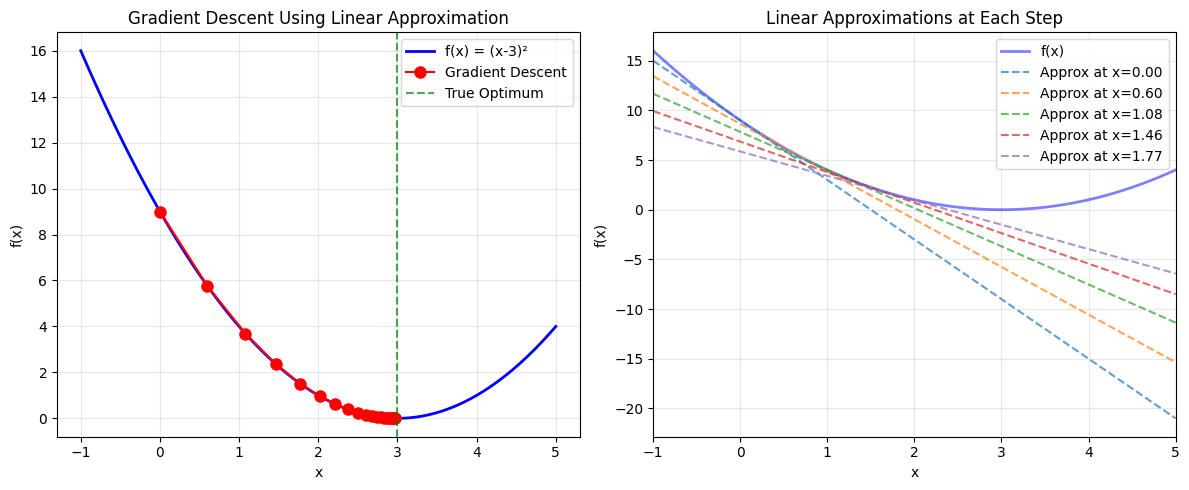


✅ Linear approximation used for gradient descent optimization!


In [4]:
# Use the 1st-order (linear) approximation to derive gradient descent and run it on (x-3)^2.
# Each step follows the tangent line downhill — the right panel draws those tangent lines.

print("\n" + "=" * 60)
print("Part 3: Linear Approximation for Optimization")
print("=" * 60)

# Linear approximation is used in gradient descent
# f(x) ≈ f(x0) + f'(x0)(x - x0)
# For optimization: x_new = x_old - learning_rate * f'(x_old)

def gradient_descent_with_approximation(f, df, x0, learning_rate=0.1, n_iter=50):
    """Gradient descent using linear approximation"""
    x = x0
    history = [x]
    values = [f(x)]
    for i in range(n_iter):
        x = x - learning_rate * df(x)
        history.append(x)
        values.append(f(x))
    return x, history, values

# Example: Minimize f(x) = (x - 3)^2
def f_example(x):
    return (x - 3)**2

def df_example(x):
    return 2 * (x - 3)

x0 = 0.0
x_opt, history, values = gradient_descent_with_approximation(f_example, df_example, x0, learning_rate=0.1, n_iter=20)

print(f"\nStarting point: x0 = {x0}")
print(f"Optimal point: x* = {x_opt:.4f} (true optimum: 3.0)")
print(f"Final function value: f(x*) = {f_example(x_opt):.6f}")

# Visualize
x_range = np.linspace(-1, 5, 100)
y_range = [f_example(x) for x in x_range]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x_range, y_range, 'b-', label='f(x) = (x-3)²', linewidth=2)
plt.plot(history, values, 'ro-', label='Gradient Descent', markersize=8)
plt.axvline(x=3, color='g', linestyle='--', label='True Optimum', alpha=0.7)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Gradient Descent Using Linear Approximation')
plt.legend()
plt.grid(True, alpha=0.3)

# Show linear approximations at each step
plt.subplot(1, 2, 2)
plt.plot(x_range, y_range, 'b-', label='f(x)', linewidth=2, alpha=0.5)
for i, x_i in enumerate(history[:5]):
 # Linear approximation: f(x) ≈ f(x_i) + f'(x_i)(x - x_i)
 y_i = f_example(x_i)
 df_i = df_example(x_i)
 approx = [y_i + df_i * (x - x_i) for x in x_range]
 plt.plot(x_range, approx, '--', alpha=0.7, label=f'Approx at x={x_i:.2f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Linear Approximations at Each Step')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-1, 5)

plt.tight_layout()
plt.show()

print("\n✅ Linear approximation used for gradient descent optimization!")

**Read the figure.** Both panels are the same run of gradient descent on f(x) = (x − 3)², started at
x = 0 with a learning rate of 0.1.

- **Left** — the red dots are the parameter values actually visited. They are **widely spaced at the start
  and packed together near x = 3**, because each move is −lr × f'(x) and the slope flattens as the curve
  bottoms out. The green dashed line is the true optimum; the run ends at x = 2.9654, close to 3 but never exactly on it.
- **Right** — the same steps, but now each is shown as what the algorithm actually used: a **tangent line**.
  Five of them are drawn, at x = 0.00, 0.60, 1.08, 1.46 and 1.77. Each one touches f at its own point and
  slopes **down to the right**, telling the algorithm which way to move. Notice they get **progressively
  less steep** as the run approaches the minimum — the blue tangent at x = 0 is the steepest, the purple
  one at x = 1.77 the shallowest.
- Notice also how badly the tangents fail away from their touch point: extended to x = 5 the steepest of them
  dives to about −21, while the true blue curve has turned back up to +4. **A linear approximation is only trustworthy
  near where it was built** — which is the whole reason the step is multiplied by a small learning rate
  instead of following the tangent all the way to where it predicts zero loss.


---

## ⚠️ Where this breaks

- **Taylor series are local, and the notebook's own figure shows it.** The Part 1 curves track exp and sin
  closely near the expansion point and then peel away. A five-term Taylor series of sin(x) around 0 is
  useless by x = 6. Every "second-order method" in optimisation inherits that radius: it trusts the
  quadratic model only inside a small region, which is exactly what a *trust region* is.
- **The 1.41e-10 match in Part 2 is not evidence that quadratic approximation works in general.** It is
  evidence that *this particular loss is exactly quadratic*: for linear regression with MSE, the second-order
  Taylor expansion is not an approximation at all — it is the function, as the printed note says. Carry that
  number over to a neural network's loss and you will be badly wrong; there the same expansion is a local
  likeness, valid in a small ball whose radius nobody tells you.
- **Universal approximation is an existence theorem.** No width bound, no training guarantee, no statement
  about unseen data. The cheaper alternative when your function is genuinely simple: a polynomial or a
  linear model with well-chosen features will approximate it with far fewer parameters, far less data and
  a fit you can explain — Course 04, Unit 1 spends a whole unit on that trade.


---

## 💬 Discuss

1. The universal approximation theorem guarantees that suitable weights exist. Gradient descent gives no
   guarantee of finding them. If both statements are true, what is a paper actually claiming when it opens
   with "neural networks are universal approximators"?
2. Part 2's quadratic approximation matched the real loss surface to 1e-10 — because the loss *was*
   quadratic. Describe an experiment you could run on a neural network's loss to find out how far from the
   current point the quadratic picture stays useful.
3. A client wants a model to predict monthly demand from four inputs, with 60 historical months of data.
   Universal approximation says a neural network can represent the relationship. Argue for a linear model
   anyway, and say what evidence would change your recommendation.


## Summary

### Key Concepts:
1. **Taylor Series**: Approximate functions using power series
2. **Linear Approximation**: f(x) ≈ f(a) + f'(a)(x-a)
3. **Quadratic Approximation**: Includes second-order terms (Hessian)
4. **Optimization**: Use approximations to find optimal points
5. **Gradient Descent**: Uses linear approximation to minimize functions

### Best Practices:
- Use Taylor series for local approximations
- Verify approximations near the expansion point
- Higher-order terms improve accuracy
- Linear approximation sufficient for gradient descent

### Applications:
- Function optimization
- Gradient descent algorithms
- Understanding loss surfaces
- Model behavior analysis

**Reference:** Course 03, Unit 2: "Calculus for Machine Learning" - Function approximation practical content

## 📚 References

1. Cybenko, G. (1989). *Approximation by Superpositions of a Sigmoidal Function*. Mathematics of Control, Signals and Systems, 2, 303–314.
2. Hornik, K., Stinchcombe, M., & White, H. (1989). *Multilayer Feedforward Networks Are Universal Approximators*. Neural Networks, 2(5), 359–366.
3. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 6: Deep Feedforward Networks. MIT Press. <https://www.deeplearningbook.org/>
4. Liu, Z., Wang, Y., Vaidya, S., Ruehle, F., Halverson, J., Soljačić, M., Hou, T. Y., & Tegmark, M. (2024). *KAN: Kolmogorov-Arnold Networks*. arXiv. <https://arxiv.org/abs/2404.19756> — a 2024 architecture built directly on a function-approximation theorem rather than on stacked linear layers.
5. Blondel, M., & Roulet, V. (2024). *The Elements of Differentiable Programming*. arXiv. <https://arxiv.org/abs/2403.14606> — how approximation and differentiation fit together in current machine-learning practice.
